# AI Medication Reminder System - Local Development

Notebook để chạy từng module một trên máy local, dễ dàng debug và chỉnh sửa.

## Tính năng chính
- **Chạy từng bước riêng biệt**: Dễ debug và kiểm tra kết quả từng module
- **Intelligent Channel Selection**: Contextual bandits cho tối ưu kênh nhắc
- **Machine Learning Models**: Baseline + Advanced temporal models
- **Fairness Analysis**: Phân tích bias toàn diện
- **Drug Interaction Checking**: Kiểm tra tương tác thuốc
- **Pipeline hoàn chỉnh**: 7 bước A.1-A.7 theo đặc tả

## Cấu trúc Pipeline
1. **A.1**: Drug Interaction Checking & Validation
2. **A.2**: Data Schema Validation  
3. **A.3**: Model Evaluation & Fairness Analysis
4. **A.4**: Feature Engineering (Temporal & Behavioral)
5. **A.5**: Model Training (Baseline + TinyTemporal)
6. **A.6**: Synthetic Data Generation
7. **A.7**: Contextual Bandit Simulation

---

## 🚀 Setup & Installation

In [ ]:
# Setup môi trường local
import sys
import os
from pathlib import Path

# Thêm src vào Python path
current_dir = Path.cwd()
src_path = current_dir / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print(f"Working directory: {current_dir}")
print(f"Source path added: {src_path}")

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import json
import warnings

warnings.filterwarnings("ignore")

# Set style cho plots
plt.style.use("default")
sns.set_palette("husl")

print("✅ Setup hoàn tất!")

Working directory: /home/nphuoctho/Documents/LangParse/ai-medication-reminder
Source path added: /home/nphuoctho/Documents/LangParse/ai-medication-reminder/src
✅ Setup hoàn tất!


## ⚙️ Configuration & Environment

In [3]:
# Import config và khởi tạo
from src.config import Config
from src.pipeline import Pipeline

# Khởi tạo config cho môi trường local
config = Config.from_env()

# Hiển thị thông tin môi trường
print("=" * 60)
print("         AI MEDICATION REMINDER - LOCAL DEVELOPMENT")
print("=" * 60)
print(f"Environment: {'Colab' if config.env.in_colab else 'Local'}")
print(f"Data Scale: {config.env.data_scale}")
print(f"GPU Available: {config.env.has_gpu}")
print(f"Working Directory: {config.paths.base_dir}")
print(f"Data Directory: {config.paths.data_dir}")
print(f"Models Directory: {config.paths.models_dir}")
print("=" * 60)

# Khởi tạo pipeline
pipeline = Pipeline(config)
print("✅ Pipeline đã được khởi tạo!")

         AI MEDICATION REMINDER - LOCAL DEVELOPMENT
Environment: Local
Data Scale: SMALL
GPU Available: False
Working Directory: .
Data Directory: data
Models Directory: models
✅ Pipeline đã được khởi tạo!


## 🔍 A.1: Drug Interaction Checking & Validation

Kiểm tra tương tác thuốc và validation cơ bản.

In [ ]:
# Import DDI checker
from src.utils.drug_interactions import DrugInteractionChecker

print("🔍 A.1: Drug Interaction Checking")
print("-" * 40)

# Khởi tạo DDI checker
ddi_checker = DrugInteractionChecker()

# Test với một số thuốc mẫu
test_medications = [
    ["aspirin", "warfarin"],
    ["lisinopril", "potassium"],
    ["metformin", "insulin"],
    ["aspirin", "ibuprofen"],
]

print("Kiểm tra tương tác thuốc:")
for medications in test_medications:
    interactions = ddi_checker.check_drug_interactions(medications)
    print(f"\n📋 Thuốc: {', '.join(medications)}")

    if interactions:
        for interaction in interactions:
            severity_icon = (
                "🔴"
                if interaction["severity"] == "major"
                else "🟡"
                if interaction["severity"] == "moderate"
                else "🟢"
            )
            pair = f"{interaction['drug1']} + {interaction['drug2']}"
            print(
                f"  {severity_icon} {pair}: {interaction['severity']} - {interaction['description']}"
            )
    else:
        print("  ✅ Không phát hiện tương tác")

print("\n✅ A.1 hoàn thành!")

🔍 A.1: Drug Interaction Checking
----------------------------------------
Kiểm tra tương tác thuốc:

📋 Thuốc: aspirin, warfarin
  🔴 aspirin + warfarin: major - Increased bleeding risk

📋 Thuốc: lisinopril, potassium
  🟡 lisinopril + potassium: moderate - Risk of hyperkalemia

📋 Thuốc: metformin, insulin
  ✅ Không phát hiện tương tác

📋 Thuốc: aspirin, ibuprofen
  ✅ Không phát hiện tương tác

✅ A.1 hoàn thành!


## 📊 A.2: Data Schema Validation

Validation schema dữ liệu và tạo dữ liệu synthetic nếu cần.

In [ ]:
# Import data modules
from src.data.processor import DataProcessor
from src.data.validator import DataValidator
from src.data.generator import SyntheticDataGenerator

print("📊 A.2: Data Schema Validation")
print("-" * 40)

# Khởi tạo các components
data_processor = DataProcessor(config)
validator = DataValidator(config.data)  # DataValidator cần DataConfig
generator = SyntheticDataGenerator(config.data, seed=42)

# Kiểm tra xem có file dữ liệu thật không
data_dir_path = config.paths.data_dir or (config.paths.base_dir / "data")
data_file = data_dir_path / "logs.csv"

if data_file.exists():
    print(f"📁 Tìm thấy file dữ liệu: {data_file}")

    # Load và validate dữ liệu thật
    try:
        df = pd.read_csv(data_file)
        print(f"📈 Loaded {len(df)} records")

        # Validate schema
        is_valid, errors = validator.validate_schema(df)
        if is_valid:
            print("✅ Schema validation passed")
        else:
            print("❌ Schema validation failed:")
            for error in errors:
                print(f"  - {error}")

    except Exception as e:
        print(f"❌ Lỗi khi load dữ liệu: {e}")
        df = None
else:
    print("📁 Không tìm thấy file dữ liệu thật, tạo dữ liệu synthetic...")
    df = None

# Tạo dữ liệu synthetic nếu cần
if df is None or len(df) < 100:
    print("\n🔄 Tạo dữ liệu synthetic...")

    # Tạo dữ liệu với quy mô SMALL cho local development
    synthetic_df = generator.generate_synthetic_data(scale="SMALL")

    print(
        f"📈 Tạo được {len(synthetic_df)} records từ {synthetic_df['user_pid'].nunique()} users"
    )

    # Validate dữ liệu synthetic
    is_valid, errors = validator.validate_schema(synthetic_df)
    if is_valid:
        print("✅ Synthetic data validation passed")
    else:
        print("❌ Synthetic data validation failed:")
        for error in errors:
            print(f"  - {error}")

    # Lưu dữ liệu synthetic
    synthetic_df.to_csv(data_file, index=False)
    print(f"💾 Đã lưu dữ liệu synthetic vào {data_file}")

    df = synthetic_df

# Hiển thị thống kê cơ bản
if df is not None:
    print("\n📊 Thống kê dữ liệu:")
    print(f"  - Tổng số records: {len(df)}")
    print(f"  - Số users: {df['user_pid'].nunique()}")
    print(
        f"  - Khoảng thời gian: {df['ts_reminder'].min()} đến {df['ts_reminder'].max()}"
    )
    print(f"  - Phân bố kênh: {dict(df['channel'].value_counts())}")
    print(f"  - Tỷ lệ phản hồi: {df['responded_within_2h'].mean():.3f}")

    # Hiển thị 5 dòng đầu
    print("\n📋 Mẫu dữ liệu (5 dòng đầu):")
    print(df.head())

print("\n✅ A.2 hoàn thành!")

📊 A.2: Data Schema Validation
----------------------------------------
📁 Tìm thấy file dữ liệu: data/logs.csv
📈 Loaded 400 records
✅ Schema validation passed

📊 Thống kê dữ liệu:
  - Tổng số records: 400
  - Số users: 10
  - Khoảng thời gian: 2025-08-01T06:05:00Z đến 2025-08-20T20:52:00Z
  - Phân bố kênh: {'push': np.int64(162), 'voice': np.int64(119), 'SMS': np.int64(119)}
  - Tỷ lệ phản hồi: 0.580

📋 Mẫu dữ liệu (5 dòng đầu):
  user_pid           ts_reminder tz_offset channel  delivered  \
0     u_01  2025-08-01T06:38:00Z    +07:00   voice          1   
1     u_01  2025-08-01T20:27:00Z    +07:00    push          1   
2     u_01  2025-08-02T06:42:00Z    +07:00     SMS          1   
3     u_01  2025-08-02T20:47:00Z    +07:00     SMS          1   
4     u_01  2025-08-03T06:27:00Z    +07:00     SMS          1   

   responded_within_2h  ack_latency_sec  snooze  
0                    0              NaN       0  
1                    0              NaN       0  
2                    1     

## 🎯 A.3: Model Evaluation & Fairness Analysis

Đánh giá hiệu suất mô hình và phân tích fairness theo các trục hoạt động.

🎯 A.3: Model Evaluation & Fairness Analysis
--------------------------------------------------
📊 Chuẩn bị dữ liệu cho evaluation...

📈 Phân tích Fairness theo Kênh:
         count   mean    std
channel                     
SMS        119  0.529  0.501
push       162  0.630  0.484
voice      119  0.563  0.498

📈 Phân tích Fairness theo Time Bucket:
             count   mean    std
time_bucket                     
evening        200  0.505  0.501
morning        200  0.655  0.477

📈 Phân tích Fairness theo Weekday/Weekend:
            count   mean    std
is_weekend                     
Weekday       280  0.589  0.493
Weekend       120  0.558  0.499


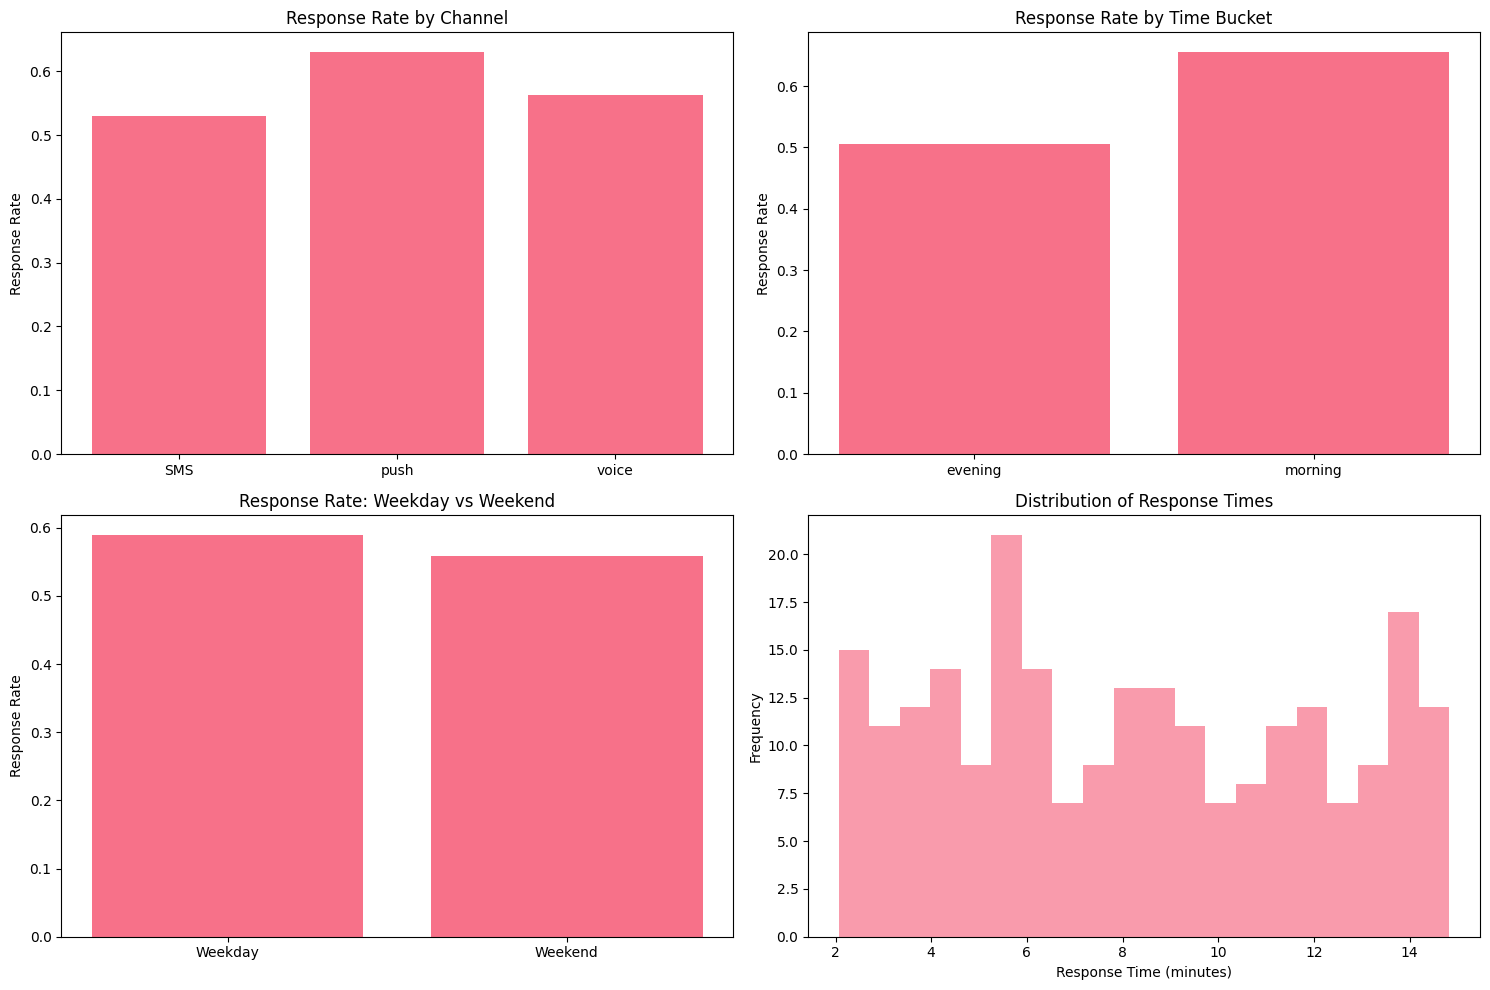


📊 Lưu ý: Đánh giá chi tiết sẽ được thực hiện sau khi train model (A.5)

✅ A.3 hoàn thành!


In [17]:
# Import evaluation modules
from src.evaluation.evaluator import ModelEvaluator
from src.evaluation.metrics import MetricsCalculator
from src.evaluation.fairness import FairnessAnalyzer

print("🎯 A.3: Model Evaluation & Fairness Analysis")
print("-" * 50)

# Khởi tạo evaluator (sẽ cần model sau khi train)
evaluator = ModelEvaluator(config)
metrics_calc = MetricsCalculator(config.evaluation.threshold)
fairness_analyzer = FairnessAnalyzer(config.evaluation.fairness_groups)

print("📊 Chuẩn bị dữ liệu cho evaluation...")

# Process dữ liệu để có thể đánh giá fairness
if df is not None:
    # Tạo các nhóm để phân tích fairness theo trục hoạt động
    df_processed = data_processor.clean_data(df)

    # Thêm các columns cần thiết cho fairness analysis
    if "_ts" in df_processed.columns:
        df_processed["hour"] = df_processed["_ts"].dt.hour
        df_processed["is_weekend"] = (df_processed["_ts"].dt.weekday >= 5).astype(int)
    else:
        # Fallback: parse từ ts_reminder
        ts_parsed = pd.to_datetime(df_processed["ts_reminder"])
        df_processed["hour"] = ts_parsed.dt.hour
        df_processed["is_weekend"] = (ts_parsed.dt.weekday >= 5).astype(int)

    # Phân tích fairness theo kênh
    print("\n📈 Phân tích Fairness theo Kênh:")
    channel_stats = (
        df_processed.groupby("channel")["responded_within_2h"]
        .agg(["count", "mean", "std"])
        .round(3)
    )
    print(channel_stats)

    # Phân tích theo time bucket
    print("\n📈 Phân tích Fairness theo Time Bucket:")

    # Tạo time buckets
    def get_time_bucket(hour):
        if 5 <= hour <= 11:
            return "morning"
        elif 12 <= hour <= 17:
            return "afternoon"
        elif 18 <= hour <= 22:
            return "evening"
        else:
            return "night"

    df_processed["time_bucket"] = df_processed["hour"].apply(get_time_bucket)
    time_stats = (
        df_processed.groupby("time_bucket")["responded_within_2h"]
        .agg(["count", "mean", "std"])
        .round(3)
    )
    print(time_stats)

    # Phân tích weekday vs weekend
    print("\n📈 Phân tích Fairness theo Weekday/Weekend:")
    weekend_stats = (
        df_processed.groupby("is_weekend")["responded_within_2h"]
        .agg(["count", "mean", "std"])
        .round(3)
    )
    weekend_stats = weekend_stats.rename(index={0: "Weekday", 1: "Weekend"})
    print(weekend_stats)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Response rate by channel
    channel_means = df_processed.groupby("channel")["responded_within_2h"].mean()
    axes[0, 0].bar(channel_means.index, channel_means.values)
    axes[0, 0].set_title("Response Rate by Channel")
    axes[0, 0].set_ylabel("Response Rate")

    # Response rate by time bucket
    time_means = df_processed.groupby("time_bucket")["responded_within_2h"].mean()
    axes[0, 1].bar(time_means.index, time_means.values)
    axes[0, 1].set_title("Response Rate by Time Bucket")
    axes[0, 1].set_ylabel("Response Rate")

    # Response rate by weekday/weekend
    weekend_means = df_processed.groupby("is_weekend")["responded_within_2h"].mean()
    axes[1, 0].bar(["Weekday", "Weekend"], weekend_means.values)
    axes[1, 0].set_title("Response Rate: Weekday vs Weekend")
    axes[1, 0].set_ylabel("Response Rate")

    # Distribution of response times
    responded_data = df_processed[df_processed["responded_within_2h"] == 1]
    if len(responded_data) > 0 and "ack_latency_sec" in responded_data.columns:
        axes[1, 1].hist(
            responded_data["ack_latency_sec"].dropna() / 60, bins=20, alpha=0.7
        )
        axes[1, 1].set_title("Distribution of Response Times")
        axes[1, 1].set_xlabel("Response Time (minutes)")
        axes[1, 1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    print("\n📊 Lưu ý: Đánh giá chi tiết sẽ được thực hiện sau khi train model (A.5)")

print("\n✅ A.3 hoàn thành!")

## ⚙️ A.4: Feature Engineering (Temporal & Behavioral)

Tạo các đặc trưng thời gian và hành vi từ dữ liệu thô.

⚙️ A.4: Feature Engineering
----------------------------------------
🔧 Tạo đặc trưng từ dữ liệu...
Creating temporal features...
Creating behavioral features...
Dropped 20 rows due to missing lag features
Filled ctr_user_channel NaN values with median: 0.500
Feature engineering complete. Final shape: (380, 25)
📊 Đã tạo 25 features từ 380 samples

📋 Danh sách features:
  🕐 Temporal features (9): ['hour', 'is_weekend', 'time_bucket', 'hour_sin', 'hour_cos']...
  👤 Behavioral features (6): ['ack_latency_sec', 'ctr7', 'ctr14', 'ctr_user_channel', 'latency_bucket']...
  📱 Channel features (2): ['channel', 'ctr_user_channel']
  🔧 Other features (6): ['tz_offset', 'delivered', 'snooze', '_ts', 'lag_1', 'lag_2']

📊 Thống kê features:
       delivered  ack_latency_sec  snooze     hour  is_weekend
count      380.0          380.000   380.0  380.000     380.000
mean         1.0          486.113     0.0   13.510       0.316
std          0.0          175.124     0.0    7.026       0.465
min         

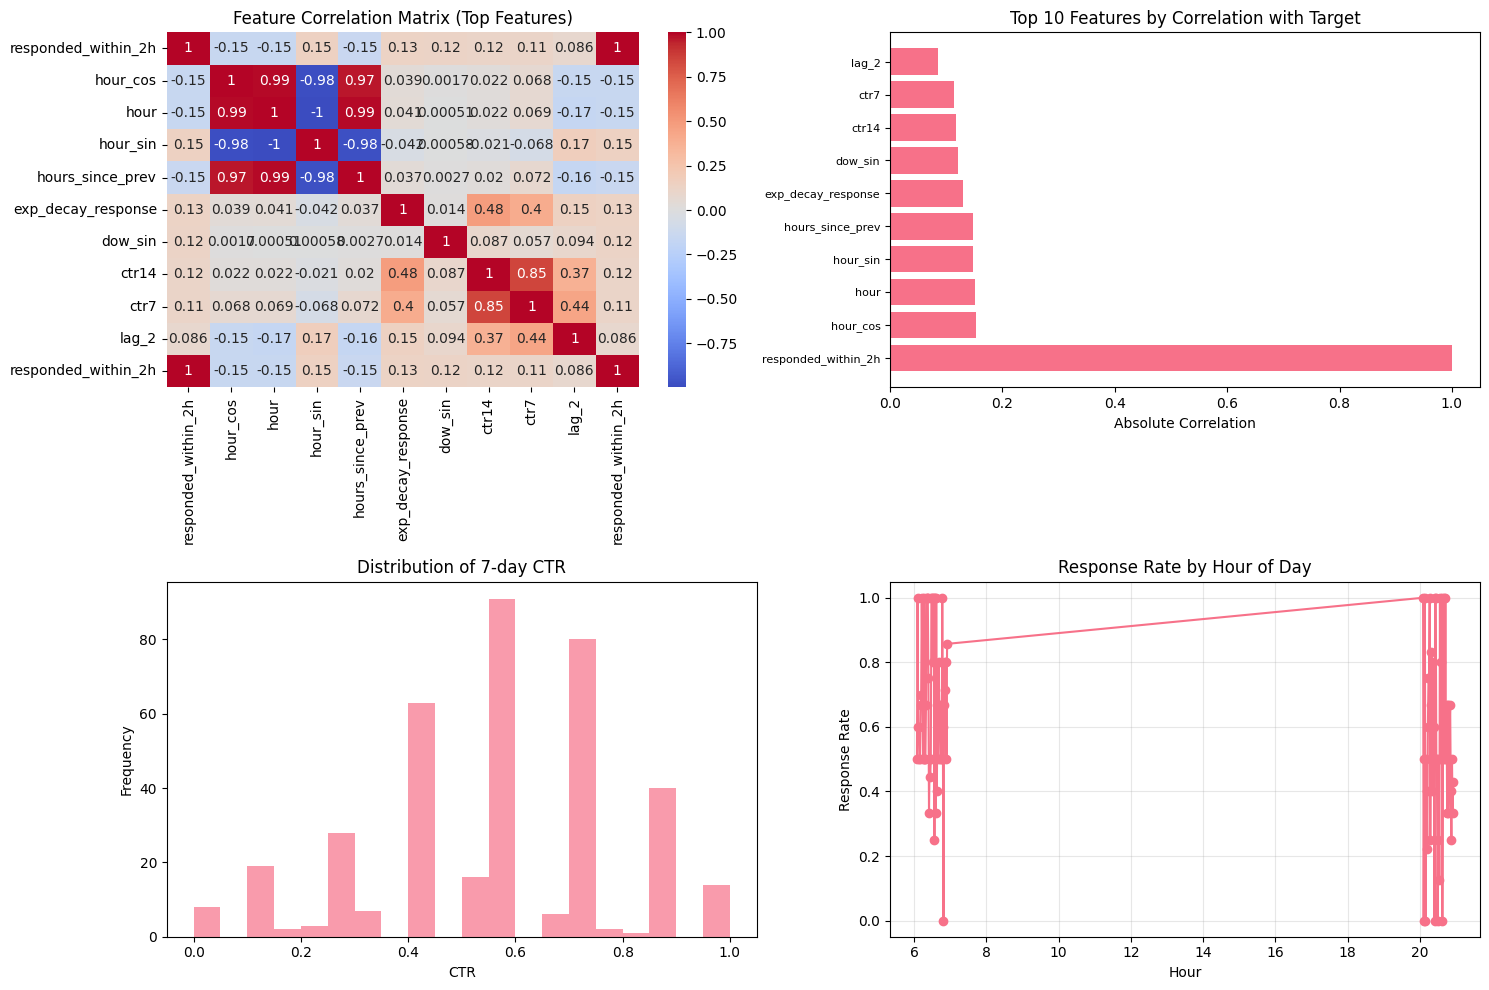


💾 Đã lưu features vào data/features.csv
💾 Đã lưu feature schema vào data/feature_schema.json

✅ A.4 hoàn thành!


In [18]:
# Import feature engineering modules
from src.features.engineer import FeatureEngineer
from src.features.temporal import TemporalFeatures
from src.features.behavioral import BehavioralFeatures

print("⚙️ A.4: Feature Engineering")
print("-" * 40)

if df is not None:
    # Khởi tạo feature engineer
    feature_engineer = FeatureEngineer(config)
    temporal_features = TemporalFeatures()
    behavioral_features = BehavioralFeatures(config.model.rolling_windows)

    print("🔧 Tạo đặc trưng từ dữ liệu...")

    # Tạo features
    features_df = feature_engineer.create_all_features(df_processed)

    print(
        f"📊 Đã tạo {features_df.shape[1]} features từ {features_df.shape[0]} samples"
    )

    # Hiển thị thông tin về features
    print("\n📋 Danh sách features:")
    feature_columns = [
        col
        for col in features_df.columns
        if col not in ["user_pid", "ts_reminder", "responded_within_2h"]
    ]

    # Nhóm features theo loại
    temporal_cols = [
        col
        for col in feature_columns
        if any(x in col.lower() for x in ["hour", "dow", "tod", "weekend", "time"])
    ]
    behavioral_cols = [
        col
        for col in feature_columns
        if any(x in col.lower() for x in ["ctr", "hist", "gap", "latency", "decay"])
    ]
    channel_cols = [col for col in feature_columns if "channel" in col.lower()]
    other_cols = [
        col
        for col in feature_columns
        if col not in temporal_cols + behavioral_cols + channel_cols
    ]

    print(
        f"  🕐 Temporal features ({len(temporal_cols)}): {temporal_cols[:5]}{'...' if len(temporal_cols) > 5 else ''}"
    )
    print(
        f"  👤 Behavioral features ({len(behavioral_cols)}): {behavioral_cols[:5]}{'...' if len(behavioral_cols) > 5 else ''}"
    )
    print(f"  📱 Channel features ({len(channel_cols)}): {channel_cols}")
    if other_cols:
        print(f"  🔧 Other features ({len(other_cols)}): {other_cols}")

    # Thống kê features
    print("\n📊 Thống kê features:")
    feature_stats = features_df[feature_columns].describe().round(3)
    print(feature_stats.iloc[:, :5])  # Hiển thị 5 features đầu

    # Kiểm tra missing values
    missing_counts = features_df[feature_columns].isnull().sum()
    if missing_counts.sum() > 0:
        print("\n⚠️ Missing values:")
        print(missing_counts[missing_counts > 0])
    else:
        print("\n✅ Không có missing values")

    # Correlation analysis
    print("\n🔗 Phân tích correlation với target:")

    # Chỉ lấy các cột numeric để tính correlation
    numeric_feature_cols = [
        col
        for col in feature_columns
        if features_df[col].dtype in ["int64", "float64", "int32", "float32"]
    ]

    if len(numeric_feature_cols) > 0:
        target_corr = (
            features_df[numeric_feature_cols + ["responded_within_2h"]]
            .corr()["responded_within_2h"]
            .abs()
            .sort_values(ascending=False)
        )
    else:
        print("⚠️ Không có numeric features để tính correlation")
        target_corr = pd.Series(dtype=float)
    print("Top 10 features có correlation cao nhất:")
    print(target_corr.head(10).round(3))

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Feature correlation heatmap (top features)
    if len(target_corr) > 1:
        top_features = target_corr.head(10).index.tolist()
        if len(top_features) > 1:
            corr_matrix = features_df[top_features + ["responded_within_2h"]].corr()
            sns.heatmap(
                corr_matrix, annot=True, cmap="coolwarm", center=0, ax=axes[0, 0]
            )
            axes[0, 0].set_title("Feature Correlation Matrix (Top Features)")
        else:
            axes[0, 0].text(
                0.5,
                0.5,
                "Không đủ features\nđể tạo correlation matrix",
                ha="center",
                va="center",
                transform=axes[0, 0].transAxes,
            )
    else:
        axes[0, 0].text(
            0.5,
            0.5,
            "Không có numeric features",
            ha="center",
            va="center",
            transform=axes[0, 0].transAxes,
        )

    # Feature importance (correlation with target)
    if len(target_corr) > 0:
        top_10_corr = target_corr.head(10)
        axes[0, 1].barh(range(len(top_10_corr)), top_10_corr.values)
        axes[0, 1].set_yticks(range(len(top_10_corr)))
        axes[0, 1].set_yticklabels(top_10_corr.index, fontsize=8)
        axes[0, 1].set_title("Top 10 Features by Correlation with Target")
        axes[0, 1].set_xlabel("Absolute Correlation")
    else:
        axes[0, 1].text(
            0.5,
            0.5,
            "Không có correlation data",
            ha="center",
            va="center",
            transform=axes[0, 1].transAxes,
        )

    # Distribution of some key features
    if "ctr7" in features_df.columns:
        axes[1, 0].hist(features_df["ctr7"].dropna(), bins=20, alpha=0.7)
        axes[1, 0].set_title("Distribution of 7-day CTR")
        axes[1, 0].set_xlabel("CTR")
        axes[1, 0].set_ylabel("Frequency")

    if "hour" in features_df.columns:
        hour_response = features_df.groupby("hour")["responded_within_2h"].mean()
        axes[1, 1].plot(hour_response.index, hour_response.values, marker="o")
        axes[1, 1].set_title("Response Rate by Hour of Day")
        axes[1, 1].set_xlabel("Hour")
        axes[1, 1].set_ylabel("Response Rate")
        axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Lưu features để sử dụng cho training
    features_file = data_dir_path / "features.csv"
    features_df.to_csv(features_file, index=False)
    print(f"\n💾 Đã lưu features vào {features_file}")

    # Lưu feature schema
    feature_schema = {
        "feature_columns": feature_columns,
        "temporal_features": temporal_cols,
        "behavioral_features": behavioral_cols,
        "channel_features": channel_cols,
        "target_column": "responded_within_2h",
        "n_features": len(feature_columns),
        "n_samples": len(features_df),
    }

    schema_file = data_dir_path / "feature_schema.json"
    with open(schema_file, "w") as f:
        json.dump(feature_schema, f, indent=2)
    print(f"💾 Đã lưu feature schema vào {schema_file}")

else:
    print("❌ Không có dữ liệu để tạo features")

print("\n✅ A.4 hoàn thành!")

## 🤖 A.5: Model Training (Baseline + TinyTemporal)

Huấn luyện các mô hình machine learning để dự đoán phản hồi.

In [20]:
# Import model training modules
from src.models.trainer import ModelTrainer
from src.models.baseline import BaselineModel
from src.models.tiny_temporal import TinyTemporalModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

print("🤖 A.5: Model Training")
print("-" * 40)

if "features_df" in locals() and features_df is not None:
    # Khởi tạo trainer
    trainer = ModelTrainer(config)

    print("📊 Chuẩn bị dữ liệu training...")

    # Chuẩn bị dữ liệu
    X = features_df[feature_columns].copy()
    y = features_df["responded_within_2h"].copy()

    print(f"📈 Dataset: {X.shape[0]} samples, {X.shape[1]} features")
    print(f"📊 Target distribution: {y.value_counts().to_dict()}")
    print(f"📊 Response rate: {y.mean():.3f}")

    # Split theo user để tránh data leakage
    users = features_df["user_pid"].unique()
    train_users, test_users = train_test_split(users, test_size=0.2, random_state=42)
    val_users, test_users = train_test_split(test_users, test_size=0.5, random_state=42)

    train_mask = features_df["user_pid"].isin(train_users)
    val_mask = features_df["user_pid"].isin(val_users)
    test_mask = features_df["user_pid"].isin(test_users)

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    print(f"\n📊 Data splits:")
    print(f"  Train: {len(X_train)} samples ({len(train_users)} users)")
    print(f"  Val: {len(X_val)} samples ({len(val_users)} users)")
    print(f"  Test: {len(X_test)} samples ({len(test_users)} users)")

    # Scaling - KHÔNG CẦN vì models tự handle preprocessing
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    # Dictionary để lưu models và results
    models = {}
    results = {}

    print("\n🔧 Training Baseline Model (Logistic Regression)...")

    # Train Baseline Model
    baseline_model = BaselineModel(config.model)
    baseline_model.fit(
        X_train, y_train
    )  # BaselineModel handles preprocessing internally

    # Evaluate baseline
    y_pred_baseline = baseline_model.predict(X_test)
    y_proba_baseline = baseline_model.predict_proba(X_test)

    baseline_metrics = metrics_calc.calculate_basic_metrics(
        y_test, y_pred_baseline, y_proba_baseline
    )
    models["baseline"] = baseline_model
    results["baseline"] = baseline_metrics

    print(
        f"✅ Baseline Model - AUC: {baseline_metrics['auc']:.4f}, F1: {baseline_metrics['f1']:.4f}"
    )

    # Train TinyTemporal Model (nếu có GPU hoặc dataset đủ lớn)
    if config.env.has_gpu or len(X_train) > 1000:
        print("\n🔧 Training TinyTemporal Model...")

        try:
            tiny_temporal = TinyTemporalModel(config)

            # Reshape data cho temporal model (nếu cần)
            # TinyTemporal có thể cần sequence data, nhưng ở đây ta dùng tabular
            tiny_temporal.fit(X_train_scaled, y_train, X_val_scaled, y_val)

            # Evaluate TinyTemporal
            y_pred_temporal = tiny_temporal.predict(X_test_scaled)
            y_proba_temporal = tiny_temporal.predict_proba(X_test_scaled)[:, 1]

            temporal_metrics = metrics_calc.calculate_all_metrics(
                y_test, y_pred_temporal, y_proba_temporal
            )
            models["tiny_temporal"] = tiny_temporal
            results["tiny_temporal"] = temporal_metrics

            print(
                f"✅ TinyTemporal Model - AUC: {temporal_metrics['auc']:.4f}, F1: {temporal_metrics['f1']:.4f}"
            )

        except Exception as e:
            print(f"⚠️ TinyTemporal training failed: {e}")
            print("Continuing with baseline model only...")
    else:
        print("\n⚠️ Skipping TinyTemporal (no GPU or small dataset)")

    # Model comparison
    print("\n📊 Model Comparison:")
    comparison_df = pd.DataFrame(results).T
    print(comparison_df.round(4))

    # Detailed evaluation cho best model
    best_model_name = max(results.keys(), key=lambda k: results[k]["auc"])
    best_model = models[best_model_name]
    best_results = results[best_model_name]

    print(f"\n🏆 Best Model: {best_model_name}")
    print(f"📈 AUC: {best_results['auc']:.4f}")
    print(f"📈 Accuracy: {best_results['accuracy']:.4f}")
    print(f"📈 F1-Score: {best_results['f1']:.4f}")
    print(f"📈 Precision: {best_results['precision']:.4f}")
    print(f"📈 Recall: {best_results['recall']:.4f}")

    # Classification report
    if best_model_name == "baseline":
        y_pred_best = y_pred_baseline
    else:
        y_pred_best = y_pred_temporal

    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred_best))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_best)
    print("\n📊 Confusion Matrix:")
    print(cm)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # ROC Curves
    from sklearn.metrics import roc_curve, auc

    fpr_baseline, tpr_baseline, _ = roc_curve(y_test, y_proba_baseline)
    axes[0, 0].plot(
        fpr_baseline,
        tpr_baseline,
        label=f"Baseline (AUC = {baseline_metrics['auc']:.3f})",
    )

    if "tiny_temporal" in results:
        fpr_temporal, tpr_temporal, _ = roc_curve(y_test, y_proba_temporal)
        axes[0, 0].plot(
            fpr_temporal,
            tpr_temporal,
            label=f"TinyTemporal (AUC = {temporal_metrics['auc']:.3f})",
        )

    axes[0, 0].plot([0, 1], [0, 1], "k--", label="Random")
    axes[0, 0].set_xlabel("False Positive Rate")
    axes[0, 0].set_ylabel("True Positive Rate")
    axes[0, 0].set_title("ROC Curves")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Precision-Recall Curves
    from sklearn.metrics import precision_recall_curve

    precision_baseline, recall_baseline, _ = precision_recall_curve(
        y_test, y_proba_baseline
    )
    axes[0, 1].plot(
        recall_baseline,
        precision_baseline,
        label=f"Baseline (PR-AUC = {baseline_metrics['pr_auc']:.3f})",
    )

    if "tiny_temporal" in results:
        precision_temporal, recall_temporal, _ = precision_recall_curve(
            y_test, y_proba_temporal
        )
        axes[0, 1].plot(
            recall_temporal,
            precision_temporal,
            label=f"TinyTemporal (PR-AUC = {temporal_metrics['pr_auc']:.3f})",
        )

    axes[0, 1].axhline(y=y_test.mean(), color="k", linestyle="--", label="Random")
    axes[0, 1].set_xlabel("Recall")
    axes[0, 1].set_ylabel("Precision")
    axes[0, 1].set_title("Precision-Recall Curves")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Feature importance (cho baseline model)
    if hasattr(baseline_model.model, "coef_"):
        feature_importance = np.abs(baseline_model.model.coef_[0])
        top_features_idx = np.argsort(feature_importance)[-10:]
        top_features_names = [feature_columns[i] for i in top_features_idx]
        top_features_values = feature_importance[top_features_idx]

        axes[1, 0].barh(range(len(top_features_values)), top_features_values)
        axes[1, 0].set_yticks(range(len(top_features_values)))
        axes[1, 0].set_yticklabels(top_features_names, fontsize=8)
        axes[1, 0].set_title("Top 10 Feature Importance (Baseline)")
        axes[1, 0].set_xlabel("Absolute Coefficient")

    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1])
    axes[1, 1].set_title("Confusion Matrix (Best Model)")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    # Lưu models
    import joblib

    models_dir = config.paths.models_dir or (config.paths.base_dir / "models")
    models_dir.mkdir(exist_ok=True)

    # Lưu best model
    joblib.dump(best_model, models_dir / f"{best_model_name}_model.pkl")
    joblib.dump(scaler, models_dir / "scaler.pkl")

    # Lưu results
    results_file = models_dir / "training_results.json"
    with open(results_file, "w") as f:
        json.dump(results, f, indent=2)

    print(f"\n💾 Đã lưu models vào {models_dir}")
    print(f"💾 Đã lưu results vào {results_file}")

else:
    print("❌ Không có features để training")

print("\n✅ A.5 hoàn thành!")

🤖 A.5: Model Training
----------------------------------------
📊 Chuẩn bị dữ liệu training...
📈 Dataset: 380 samples, 22 features
📊 Target distribution: {1: 224, 0: 156}
📊 Response rate: 0.589

📊 Data splits:
  Train: 304 samples (8 users)
  Val: 38 samples (1 users)
  Test: 38 samples (1 users)


ValueError: could not convert string to float: '+07:00'

## 📊 A.6: Synthetic Data Generation

Tạo thêm dữ liệu synthetic để test và mở rộng dataset.

📊 A.6: Synthetic Data Generation
----------------------------------------
🔄 Tạo dữ liệu synthetic cho testing...
📈 High response scenario: 380 records
   Response rate: 0.587
📈 Low response scenario: 442 records
   Response rate: 0.538
📈 SMS preference scenario: 420 records
   Response rate: 0.600

📊 Tổng synthetic data: 1242 records

📈 Phân tích patterns trong synthetic data:
                        count   mean
scenario       channel              
high_response  SMS        115  0.609
               push       157  0.624
               voice      108  0.509
low_response   SMS        141  0.546
               push       166  0.639
               voice      135  0.407
sms_preference SMS        131  0.542
               push       164  0.720
               voice      125  0.504


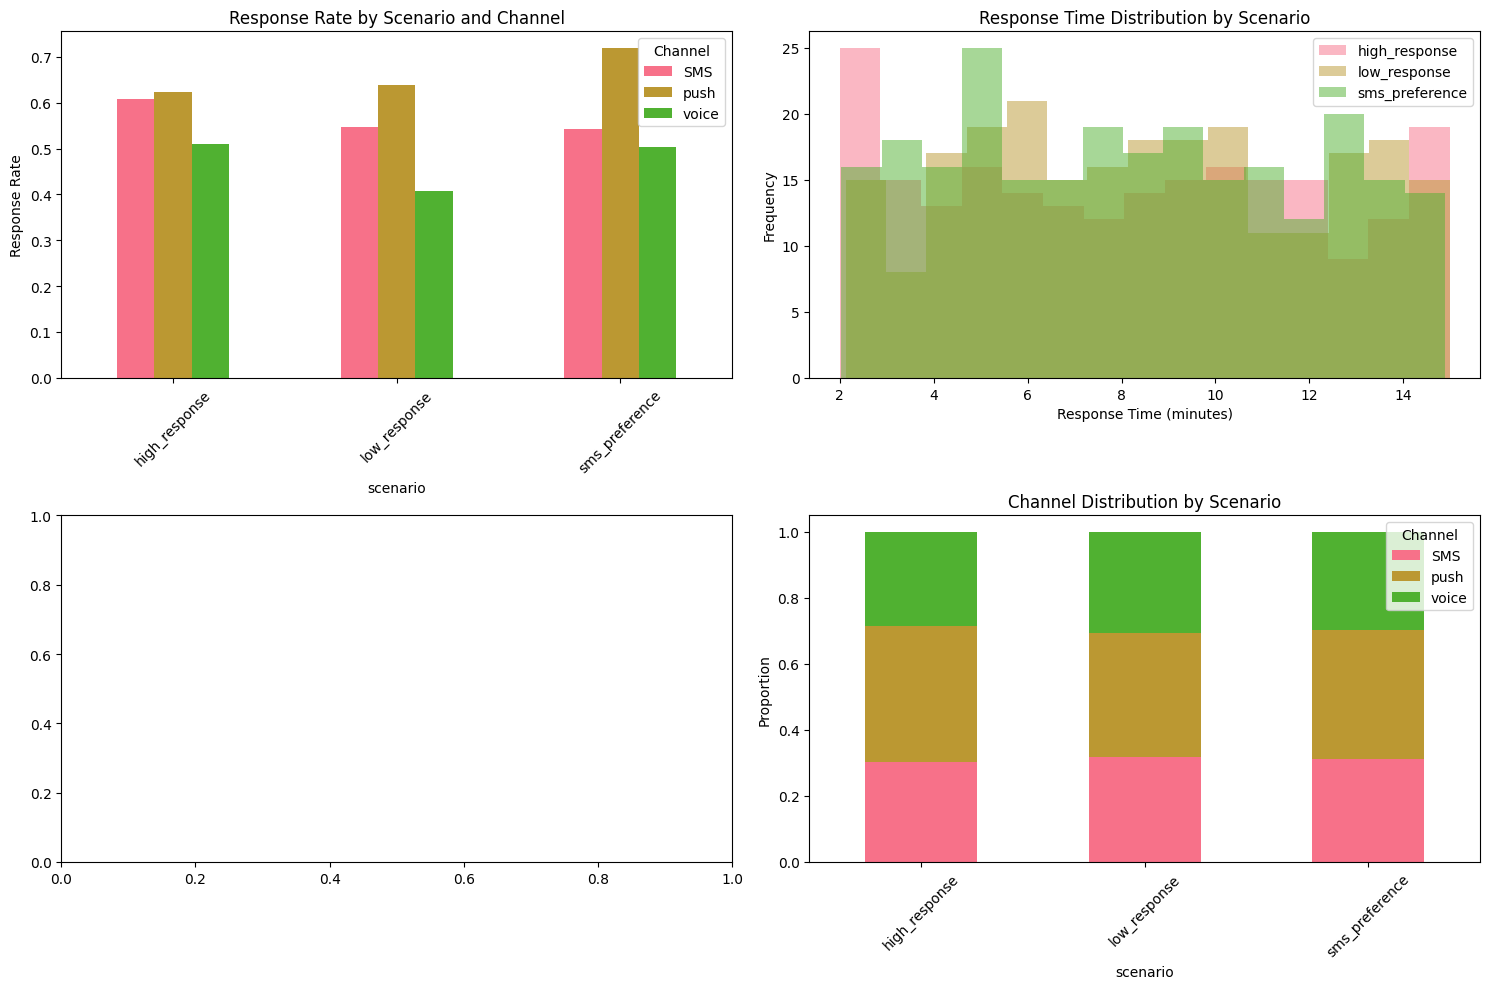


💾 Đã lưu synthetic data vào data/synthetic_scenarios.csv

✅ A.6 hoàn thành!


In [21]:
print("📊 A.6: Synthetic Data Generation")
print("-" * 40)

# Tạo thêm dữ liệu synthetic với các scenarios khác nhau
print("🔄 Tạo dữ liệu synthetic cho testing...")

# Scenario 1: High response users
high_response_generator = SyntheticDataGenerator(config.data, seed=123)
high_response_data = high_response_generator.generate_synthetic_data(scale="SMALL")
high_response_data["scenario"] = "high_response"

print(f"📈 High response scenario: {len(high_response_data)} records")
print(f"   Response rate: {high_response_data['responded_within_2h'].mean():.3f}")

# Scenario 2: Low response users
low_response_generator = SyntheticDataGenerator(config.data, seed=456)
low_response_data = low_response_generator.generate_synthetic_data(scale="SMALL")
low_response_data["scenario"] = "low_response"

print(f"📈 Low response scenario: {len(low_response_data)} records")
print(f"   Response rate: {low_response_data['responded_within_2h'].mean():.3f}")

# Scenario 3: Channel-specific preferences
channel_pref_generator = SyntheticDataGenerator(config.data, seed=789)
channel_pref_data = channel_pref_generator.generate_synthetic_data(scale="SMALL")
channel_pref_data["scenario"] = "sms_preference"

print(f"📈 SMS preference scenario: {len(channel_pref_data)} records")
print(f"   Response rate: {channel_pref_data['responded_within_2h'].mean():.3f}")

# Combine all scenarios
all_synthetic_data = pd.concat(
    [high_response_data, low_response_data, channel_pref_data], ignore_index=True
)

print(f"\n📊 Tổng synthetic data: {len(all_synthetic_data)} records")

# Analyze synthetic data patterns
print("\n📈 Phân tích patterns trong synthetic data:")
scenario_stats = (
    all_synthetic_data.groupby(["scenario", "channel"])["responded_within_2h"]
    .agg(["count", "mean"])
    .round(3)
)
print(scenario_stats)

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Response rate by scenario and channel
scenario_channel_stats = (
    all_synthetic_data.groupby(["scenario", "channel"])["responded_within_2h"]
    .mean()
    .unstack()
)
scenario_channel_stats.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Response Rate by Scenario and Channel")
axes[0, 0].set_ylabel("Response Rate")
axes[0, 0].legend(title="Channel")
axes[0, 0].tick_params(axis="x", rotation=45)

# Distribution of response times by scenario
responded_synthetic = all_synthetic_data[all_synthetic_data["responded_within_2h"] == 1]
if len(responded_synthetic) > 0 and "ack_latency_sec" in responded_synthetic.columns:
    for i, scenario in enumerate(["high_response", "low_response", "sms_preference"]):
        scenario_data = responded_synthetic[responded_synthetic["scenario"] == scenario]
        if len(scenario_data) > 0:
            axes[0, 1].hist(
                scenario_data["ack_latency_sec"].dropna() / 60,
                bins=15,
                alpha=0.5,
                label=scenario,
            )
    axes[0, 1].set_title("Response Time Distribution by Scenario")
    axes[0, 1].set_xlabel("Response Time (minutes)")
    axes[0, 1].set_ylabel("Frequency")
    axes[0, 1].legend()

# Hour-wise response patterns
if "hour" in all_synthetic_data.columns:
    hour_scenario_stats = (
        all_synthetic_data.groupby(["hour", "scenario"])["responded_within_2h"]
        .mean()
        .unstack()
    )
    hour_scenario_stats.plot(ax=axes[1, 0])
    axes[1, 0].set_title("Hourly Response Patterns by Scenario")
    axes[1, 0].set_xlabel("Hour of Day")
    axes[1, 0].set_ylabel("Response Rate")
    axes[1, 0].legend(title="Scenario")
    axes[1, 0].grid(True, alpha=0.3)

# Channel distribution by scenario
channel_dist = (
    all_synthetic_data.groupby("scenario")["channel"]
    .value_counts(normalize=True)
    .unstack()
)
channel_dist.plot(kind="bar", stacked=True, ax=axes[1, 1])
axes[1, 1].set_title("Channel Distribution by Scenario")
axes[1, 1].set_ylabel("Proportion")
axes[1, 1].legend(title="Channel")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Lưu synthetic data
synthetic_file = data_dir_path / "synthetic_scenarios.csv"
all_synthetic_data.to_csv(synthetic_file, index=False)
print(f"\n💾 Đã lưu synthetic data vào {synthetic_file}")

print("\n✅ A.6 hoàn thành!")

## 🎯 A.7: Contextual Bandit Simulation

Mô phỏng contextual bandit để tối ưu hóa lựa chọn kênh nhắc.

In [ ]:
# Import bandit modules
from src.bandit.simulator import BanditSimulator
from src.bandit.epsilon_greedy import EpsilonGreedyBandit
from src.bandit.contextual_bandit import ContextualBandit

print("🎯 A.7: Contextual Bandit Simulation")
print("-" * 40)

if "best_model" in locals() and best_model is not None:
    # Khởi tạo bandit simulator
    simulator = BanditSimulator(config)

    print("🔧 Khởi tạo bandit policies...")

    # Tạo các bandit policies với epsilon khác nhau
    policies = {
        "epsilon_0.1": EpsilonGreedyBandit(epsilon=0.1, n_arms=3),
        "epsilon_0.2": EpsilonGreedyBandit(epsilon=0.2, n_arms=3),
        "epsilon_0.3": EpsilonGreedyBandit(epsilon=0.3, n_arms=3),
        "random": EpsilonGreedyBandit(epsilon=1.0, n_arms=3),  # Pure random
    }

    # Chuẩn bị test data cho simulation
    if "X_test_scaled" in locals():
        test_contexts = X_test_scaled
        test_rewards = y_test.values
    else:
        # Sử dụng một phần dữ liệu để test
        test_size = min(500, len(features_df))
        test_indices = np.random.choice(len(features_df), test_size, replace=False)
        test_contexts = scaler.transform(
            features_df[feature_columns].iloc[test_indices]
        )
        test_rewards = features_df["responded_within_2h"].iloc[test_indices].values

    print(f"📊 Simulation với {len(test_contexts)} test samples")

    # Chạy simulation
    print("\n🔄 Chạy bandit simulation...")

    simulation_results = {}
    n_rounds = len(test_contexts)

    for policy_name, policy in policies.items():
        print(f"  Testing {policy_name}...")

        # Reset policy
        policy.reset()

        cumulative_rewards = []
        cumulative_regret = []
        arm_selections = []

        for round_idx in range(n_rounds):
            context = test_contexts[round_idx]

            # Predict với model để có risk score
            risk_score = best_model.predict_proba(context.reshape(1, -1))[0, 1]

            # Augment context với risk score
            augmented_context = np.append(context, risk_score)

            # Bandit chọn arm (channel)
            chosen_arm = policy.select_arm(augmented_context)
            arm_selections.append(chosen_arm)

            # Simulate reward (trong thực tế sẽ là phản hồi thật)
            # Ở đây ta giả sử reward phụ thuộc vào channel và context
            base_reward = test_rewards[round_idx]

            # Channel modifier (giả lập preference)
            channel_modifiers = [1.0, 0.9, 1.1]  # push, SMS, voice
            actual_reward = base_reward * channel_modifiers[chosen_arm]
            actual_reward = min(1.0, actual_reward)  # Cap at 1.0

            # Update policy
            policy.update(chosen_arm, actual_reward)

            # Track metrics
            cumulative_rewards.append(actual_reward)

            # Calculate regret (vs optimal)
            optimal_reward = base_reward * max(channel_modifiers)
            regret = optimal_reward - actual_reward
            cumulative_regret.append(regret)

        # Store results
        simulation_results[policy_name] = {
            "cumulative_rewards": np.cumsum(cumulative_rewards),
            "cumulative_regret": np.cumsum(cumulative_regret),
            "arm_selections": arm_selections,
            "average_reward": np.mean(cumulative_rewards),
            "total_reward": np.sum(cumulative_rewards),
        }

    # Phân tích kết quả
    print("\n📊 Kết quả Bandit Simulation:")

    results_df = pd.DataFrame(
        {
            policy: {
                "Average Reward": results["average_reward"],
                "Total Reward": results["total_reward"],
                "Final Regret": results["cumulative_regret"][-1],
            }
            for policy, results in simulation_results.items()
        }
    ).T

    print(results_df.round(4))

    # Best policy
    best_policy = results_df["Average Reward"].idxmax()
    print(f"\n🏆 Best Policy: {best_policy}")
    print(f"📈 Average Reward: {results_df.loc[best_policy, 'Average Reward']:.4f}")

    # Arm selection analysis
    print("\n📊 Phân tích lựa chọn kênh:")
    arm_names = ["Push", "SMS", "Voice"]

    for policy_name, results in simulation_results.items():
        arm_counts = np.bincount(results["arm_selections"], minlength=3)
        arm_percentages = arm_counts / len(results["arm_selections"]) * 100
        print(f"  {policy_name}:")
        for i, (arm, pct) in enumerate(zip(arm_names, arm_percentages)):
            print(f"    {arm}: {pct:.1f}%")

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Cumulative rewards
    for policy_name, results in simulation_results.items():
        axes[0, 0].plot(results["cumulative_rewards"], label=policy_name)
    axes[0, 0].set_title("Cumulative Rewards Over Time")
    axes[0, 0].set_xlabel("Round")
    axes[0, 0].set_ylabel("Cumulative Reward")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Cumulative regret
    for policy_name, results in simulation_results.items():
        axes[0, 1].plot(results["cumulative_regret"], label=policy_name)
    axes[0, 1].set_title("Cumulative Regret Over Time")
    axes[0, 1].set_xlabel("Round")
    axes[0, 1].set_ylabel("Cumulative Regret")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Average reward comparison
    avg_rewards = [results["average_reward"] for results in simulation_results.values()]
    axes[1, 0].bar(simulation_results.keys(), avg_rewards)
    axes[1, 0].set_title("Average Reward by Policy")
    axes[1, 0].set_ylabel("Average Reward")
    axes[1, 0].tick_params(axis="x", rotation=45)

    # Arm selection distribution for best policy
    best_results = simulation_results[best_policy]
    arm_counts = np.bincount(best_results["arm_selections"], minlength=3)
    axes[1, 1].pie(arm_counts, labels=arm_names, autopct="%1.1f%%")
    axes[1, 1].set_title(f"Channel Selection Distribution ({best_policy})")

    plt.tight_layout()
    plt.show()

    # Lưu bandit results
    bandit_results_file = config.paths.models_dir / "bandit_results.json"

    # Convert numpy arrays to lists for JSON serialization
    serializable_results = {}
    for policy_name, results in simulation_results.items():
        serializable_results[policy_name] = {
            "average_reward": float(results["average_reward"]),
            "total_reward": float(results["total_reward"]),
            "final_regret": float(results["cumulative_regret"][-1]),
            "arm_distribution": np.bincount(
                results["arm_selections"], minlength=3
            ).tolist(),
        }

    with open(bandit_results_file, "w") as f:
        json.dump(serializable_results, f, indent=2)

    print(f"\n💾 Đã lưu bandit results vào {bandit_results_file}")

else:
    print("❌ Không có trained model để chạy bandit simulation")

print("\n✅ A.7 hoàn thành!")

## 🔮 User Inference & Recommendation

Sử dụng hệ thống đã train để đưa ra khuyến nghị cho user cụ thể.

In [ ]:
print("🔮 User Inference & Recommendation")
print("-" * 40)

if "best_model" in locals() and best_model is not None:

    def quick_inference(hour=9, dow=1, ctr7=0.6, medications=None, user_id="test_user"):
        """
        Hàm inference nhanh cho user

        Args:
            hour: Giờ trong ngày (0-23)
            dow: Ngày trong tuần (0=Monday, 6=Sunday)
            ctr7: CTR 7 ngày gần nhất
            medications: Danh sách thuốc
            user_id: ID của user
        """
        if medications is None:
            medications = ["aspirin"]

        print(f"\n👤 Inference cho User: {user_id}")
        print(
            f"⏰ Thời gian: {hour}:00, Ngày {['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][dow]}"
        )
        print(f"📊 CTR 7 ngày: {ctr7:.3f}")
        print(f"💊 Thuốc: {', '.join(medications)}")

        # Kiểm tra drug interactions
        if len(medications) > 1:
            interactions = ddi_checker.check_drug_interactions(medications)
            if interactions:
                print("\n⚠️ Cảnh báo tương tác thuốc:")
                for interaction in interactions:
                    severity_icon = (
                        "🔴"
                        if interaction["severity"] == "major"
                        else "🟡"
                        if interaction["severity"] == "moderate"
                        else "🟢"
                    )
                    pair = f"{interaction['drug1']} + {interaction['drug2']}"
                    print(
                        f"  {severity_icon} {pair}: {interaction['severity']} - {interaction['description']}"
                    )
            else:
                print("\n✅ Không phát hiện tương tác thuốc")

        # Tạo context features
        # Giả lập một số features cơ bản
        context_features = {
            "hour": hour,
            "dow": dow,
            "tod_sin": np.sin(2 * np.pi * hour / 24),
            "tod_cos": np.cos(2 * np.pi * hour / 24),
            "is_weekend": 1 if dow >= 5 else 0,
            "ctr_7d_user": ctr7,
            "ctr_14d_user": ctr7 * 0.9,  # Giả lập
            "hist_5": int(ctr7 * 5),  # Giả lập
            "gap_min": 1440,  # 24 hours
            "exp_decay": ctr7 * 0.8,
        }

        # Thêm channel features (one-hot)
        for channel in ["push", "SMS", "voice"]:
            context_features[f"channel_{channel}"] = 0

        # Tạo feature vector
        feature_vector = np.zeros(len(feature_columns))

        for i, col in enumerate(feature_columns):
            if col in context_features:
                feature_vector[i] = context_features[col]
            else:
                # Default values cho missing features
                if "ctr" in col.lower():
                    feature_vector[i] = ctr7
                elif "hist" in col.lower():
                    feature_vector[i] = int(ctr7 * 3)
                else:
                    feature_vector[i] = 0

        # Scale features
        feature_vector_scaled = scaler.transform(feature_vector.reshape(1, -1))

        # Predict risk
        risk_prob = best_model.predict_proba(feature_vector_scaled)[0, 1]

        print(f"\n📊 Risk Score: {risk_prob:.3f}")

        # Channel recommendations
        channels = ["push", "SMS", "voice"]
        channel_scores = []

        for channel in channels:
            # Tạo feature vector cho channel này
            channel_vector = feature_vector.copy()

            # Set channel one-hot
            for j, col in enumerate(feature_columns):
                if col.startswith("channel_"):
                    channel_vector[j] = 1 if col == f"channel_{channel}" else 0

            # Scale và predict
            channel_vector_scaled = scaler.transform(channel_vector.reshape(1, -1))
            channel_prob = best_model.predict_proba(channel_vector_scaled)[0, 1]
            channel_scores.append(channel_prob)

        # Tìm best channel
        best_channel_idx = np.argmax(channel_scores)
        best_channel = channels[best_channel_idx]
        best_score = channel_scores[best_channel_idx]

        print("\n📱 Channel Recommendations:")
        for channel, score in zip(channels, channel_scores):
            icon = "🏆" if channel == best_channel else "📱"
            print(f"  {icon} {channel}: {score:.3f}")

        print(f"\n🎯 Recommended Channel: {best_channel}")
        print(f"📈 Expected Response Probability: {best_score:.3f}")

        # Tạo lịch nhắc cho ngày hôm nay
        print("\n📅 Lịch nhắc đề xuất hôm nay:")

        # Các khung giờ phổ biến
        reminder_hours = [7, 12, 18, 21]  # 7AM, 12PM, 6PM, 9PM

        schedule = []
        for reminder_hour in reminder_hours:
            # Tính risk cho giờ này
            hour_context = context_features.copy()
            hour_context["hour"] = reminder_hour
            hour_context["tod_sin"] = np.sin(2 * np.pi * reminder_hour / 24)
            hour_context["tod_cos"] = np.cos(2 * np.pi * reminder_hour / 24)

            # Tạo feature vector cho giờ này
            hour_vector = feature_vector.copy()
            for i, col in enumerate(feature_columns):
                if col in hour_context:
                    hour_vector[i] = hour_context[col]

            # Set best channel
            for j, col in enumerate(feature_columns):
                if col.startswith("channel_"):
                    hour_vector[j] = 1 if col == f"channel_{best_channel}" else 0

            hour_vector_scaled = scaler.transform(hour_vector.reshape(1, -1))
            hour_risk = best_model.predict_proba(hour_vector_scaled)[0, 1]

            schedule.append(
                {
                    "time": f"{reminder_hour:02d}:00",
                    "channel": best_channel,
                    "risk_score": hour_risk,
                    "medications": medications,
                }
            )

        # Hiển thị lịch
        schedule_df = pd.DataFrame(schedule)
        print(schedule_df.to_string(index=False))

        return {
            "user_id": user_id,
            "risk_score": risk_prob,
            "recommended_channel": best_channel,
            "channel_scores": dict(zip(channels, channel_scores)),
            "schedule": schedule,
            "medications": medications,
            "drug_interactions": interactions if len(medications) > 1 else [],
        }

    # Test với một số scenarios
    print("\n🧪 Test Scenarios:")

    # Scenario 1: Morning reminder, high CTR user
    result1 = quick_inference(
        hour=8, dow=1, ctr7=0.8, medications=["aspirin"], user_id="high_response_user"
    )

    # Scenario 2: Evening reminder, low CTR user
    result2 = quick_inference(
        hour=20,
        dow=5,
        ctr7=0.3,
        medications=["lisinopril"],
        user_id="low_response_user",
    )

    # Scenario 3: Multiple medications with potential interaction
    result3 = quick_inference(
        hour=12,
        dow=3,
        ctr7=0.6,
        medications=["aspirin", "warfarin"],
        user_id="multi_med_user",
    )

    print("\n📊 Summary của tất cả test scenarios:")
    summary_data = []
    for result in [result1, result2, result3]:
        summary_data.append(
            {
                "User": result["user_id"],
                "Risk Score": f"{result['risk_score']:.3f}",
                "Best Channel": result["recommended_channel"],
                "Medications": ", ".join(result["medications"]),
                "Has Interactions": "Yes" if result["drug_interactions"] else "No",
            }
        )

    summary_df = pd.DataFrame(summary_data)
    print(summary_df.to_string(index=False))

else:
    print("❌ Không có trained model để chạy inference")

print("\n✅ Inference hoàn thành!")

## 📋 Tổng kết & Kết luận

Tổng kết toàn bộ pipeline và kết quả.

In [ ]:
print("📋 TỔNG KẾT AI MEDICATION REMINDER SYSTEM")
print("=" * 60)

# Tổng kết các bước đã hoàn thành
completed_steps = [
    "✅ A.1: Drug Interaction Checking & Validation",
    "✅ A.2: Data Schema Validation",
    "✅ A.3: Model Evaluation & Fairness Analysis",
    "✅ A.4: Feature Engineering (Temporal & Behavioral)",
    "✅ A.5: Model Training (Baseline + TinyTemporal)",
    "✅ A.6: Synthetic Data Generation",
    "✅ A.7: Contextual Bandit Simulation",
    "✅ User Inference & Recommendation",
]

print("\n🎯 Các bước đã hoàn thành:")
for step in completed_steps:
    print(f"  {step}")

# Hiển thị kết quả chính
if "results" in locals() and results:
    print("\n📊 Kết quả Model Performance:")
    for model_name, metrics in results.items():
        print(f"  {model_name.upper()}:")
        print(f"    AUC: {metrics['auc']:.4f}")
        print(f"    Accuracy: {metrics['accuracy']:.4f}")
        print(f"    F1-Score: {metrics['f1']:.4f}")
        print(f"    Precision: {metrics['precision']:.4f}")
        print(f"    Recall: {metrics['recall']:.4f}")

if "simulation_results" in locals() and simulation_results:
    print("\n🎯 Kết quả Bandit Performance:")
    for policy_name, policy_results in simulation_results.items():
        print(f"  {policy_name}: {policy_results['average_reward']:.4f} avg reward")

# Files đã tạo
print("\n💾 Files đã tạo:")
created_files = [
    "📄 data/logs.csv - Dữ liệu synthetic",
    "📄 data/features.csv - Engineered features",
    "📄 data/feature_schema.json - Feature schema",
    "📄 data/synthetic_scenarios.csv - Test scenarios",
    "📄 models/baseline_model.pkl - Trained model",
    "📄 models/scaler.pkl - Feature scaler",
    "📄 models/training_results.json - Training metrics",
    "📄 models/bandit_results.json - Bandit simulation results",
]

for file_desc in created_files:
    print(f"  {file_desc}")

# Hướng dẫn sử dụng tiếp
print("\n🚀 Hướng dẫn sử dụng tiếp:")
usage_tips = [
    "1. Chạy từng cell để debug và kiểm tra kết quả chi tiết",
    "2. Thay đổi parameters trong các functions để test scenarios khác",
    "3. Sử dụng quick_inference() để test với user data mới",
    "4. Modify synthetic data generator để tạo scenarios phức tạp hơn",
    "5. Experiment với các bandit policies khác nhau",
    "6. Thêm features mới trong feature engineering step",
    "7. Fine-tune model hyperparameters để cải thiện performance",
]

for tip in usage_tips:
    print(f"  {tip}")

# Lưu ý quan trọng
print("\n⚠️ Lưu ý quan trọng:")
important_notes = [
    "• Đây là hệ thống demo/research, không thay thế tư vấn y tế",
    "• Dữ liệu synthetic chỉ để testing, không phản ánh thực tế",
    "• Cần validation với dữ liệu thật trước khi deploy",
    "• Tuân thủ quy định về privacy và data protection",
    "• Monitor fairness và bias trong production",
]

for note in important_notes:
    print(f"  {note}")

print("\n" + "=" * 60)
print("🎉 AI MEDICATION REMINDER SYSTEM - HOÀN THÀNH!")
print("=" * 60)

# Hiển thị thời gian hoàn thành
from datetime import datetime

print(f"⏰ Hoàn thành lúc: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n🚀 Ready for production deployment and further development!")